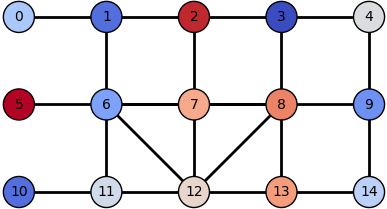

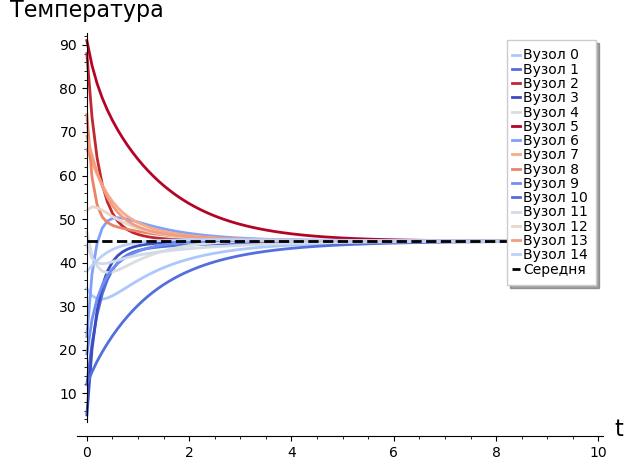

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

u1 = vector(RDF, [34, 12, 88, 5, 47, 91, 23, 66, 74, 19, 12, 44, 52, 69, 38])

data = [
    # верхня доріжка
    (0, 1), (1, 2), (2, 3), (3, 4),

    # середня доріжка
    (5, 6), (6, 7), (7, 8), (8, 9),

    # нижня доріжка
    (10, 11), (11, 12), (12, 13), (13, 14),

    # вертикальні зʼєднання
    (1, 6), (3, 8),
    (6, 11), (8, 13),

    # діагональні “трасування”
    (2, 7), (7, 12),
    (4, 9), (9, 14),

    # центральний “чіп”
    (6, 8), (6, 12), (8, 12)
]

U = Graph(data)

# Позиції, щоб виглядало як плата
pos = {
    0: (0, 2), 1: (1, 2), 2: (2, 2), 3: (3, 2), 4: (4, 2),
    5: (0, 1), 6: (1, 1), 7: (2, 1), 8: (3, 1), 9: (4, 1),
    10: (0, 0), 11: (1, 0), 12: (2, 0), 13: (3, 0), 14: (4, 0)
}

verts = U.vertices(sort=True)

A = matrix(RDF, U.adjacency_matrix(vertices=verts))
degrees = [U.degree(v) for v in verts]
D = diagonal_matrix(RDF, degrees)

L = D - A

D_mat, Q = L.eigenmatrix_right()
Q_inv = Q.inverse()

def u(t):
    exp_Lambda = diagonal_matrix(RDF, [
        exp(-D_mat[i, i] * t) for i in range(D_mat.nrows())
    ])
    return Q * exp_Lambda * Q_inv * u1

cmap = plt.get_cmap('coolwarm')
norm = colors.Normalize(vmin=min(u1), vmax=max(u1))

times = srange(0, 10, 0.1)

vals = [[] for _ in range(len(u1))]

for t in times:
    ut = u(t).n()
    for i in range(len(u1)):
        vals[i].append(ut[i])

p = Graphics()

for i in range(len(u1)):
    color = tuple(cmap(norm(u1[i]))[:3])
    p += line(
        list(zip(times, vals[i])),
        color=color,
        legend_label=f"Вузол {verts[i]}",
        thickness=2
    )

mean_val = sum(u1) / len(u1)

p += plot(
    mean_val,
    (times[0], times[-1]),
    color='black',
    linestyle='--',
    thickness=2,
    legend_label='Середня'
)

vertex_colors = {}

for i, v in enumerate(verts):
    color = tuple(cmap(norm(u1[i]))[:3])
    if color not in vertex_colors:
        vertex_colors[color] = []
    vertex_colors[color].append(v)

U.show(
    pos=pos,
    vertex_colors=vertex_colors,
    vertex_size=500,
    edge_thickness=2
)

p.axes_labels(["t", "Температура"])
show(p, legend_loc='upper right')

Граф, схожий на компʼютерну плату. Ми показуємо як змінюватиметься температура у реальній системі.